In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#Загрузка данных
df = sns.load_dataset('penguins')

In [ ]:
print("1. ДОБАВЛЕНИЕ НОВОГО АТРИБУТА")
#Добавляем новый атрибут: BMI (Body Mass Index) - отношение массы тела к длине плавника
#Для избежания деления на 0 заменяем нулевые значения на 1
df['bmi'] = df['body_mass_g'] / df['flipper_length_mm'].replace(0, 1)

#Также добавим атрибут bill_ratio (отношение длины клюва к его глубине)
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm'].replace(0, 1)

print("Добавлены новые атрибуты:")
print("bmi (индекс массы тела) = body_mass_g / flipper_length_mm")
print("bill_ratio (отношение длины клюва к глубине) = bill_length_mm / bill_depth_mm")

1. ДОБАВЛЕНИЕ НОВОГО АТРИБУТА
Добавлены новые атрибуты:
bmi (индекс массы тела) = body_mass_g / flipper_length_mm
bill_ratio (отношение длины клюва к глубине) = bill_length_mm / bill_depth_mm


In [ ]:
print("\n2. ОБРАБОТКА ДАННЫХ")

#Проверяем текущее состояние данных
print(f"\nРазмер датасета: {df.shape}")
print(f"Пропущенные значения: {df.isnull().sum().sum()}")

print(f"\nПропущенные значения для числовых колонок заполняем медианой")
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(f"Пропущенные значения для категориальных колонок заполняем модой")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

#Находим и заменяем выбросы на медиану
Q1_bmi = df['bmi'].quantile(0.25)
Q3_bmi = df['bmi'].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi
lower_bound_bmi = Q1_bmi - 1.5 * IQR_bmi
upper_bound_bmi = Q3_bmi + 1.5 * IQR_bmi

#Обрабатываем выбросы
for col in numeric_cols:
    #Проверка на выбросы
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)

    if num_outliers > 0:
        #Заменяем выбросы на медиану
        median_val = df[col].median()
        df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = median_val
        print(f"{col}: найдено {num_outliers} выбросов, заменены на медиану ({median_val:.2f})")
    else:
        print(f"{col}: выбросов не найдено")


#Удаляем дубликаты
initial_rows = df.shape[0]
df = df.drop_duplicates()
removed_duplicates = initial_rows - df.shape[0]
print(f"\nУдалено дубликатов: {removed_duplicates}")

print(f"\nРазмер датасета: {df.shape}")
print(f"Пропущенные значения: {df.isnull().sum().sum()}")


2. ОБРАБОТКА ДАННЫХ

Размер датасета: (344, 9)
Пропущенные значения: 23

Пропущенные значения для числовых колонок заполняем медианой
Пропущенные значения для категориальных колонок заполняем модой
bill_length_mm: выбросов не найдено
bill_depth_mm: выбросов не найдено
flipper_length_mm: выбросов не найдено
body_mass_g: выбросов не найдено
bmi: найдено 1 выбросов, заменены на медиану (20.52)
bill_ratio: выбросов не найдено

Удалено дубликатов: 0

Размер датасета: (344, 9)
Пропущенные значения: 0


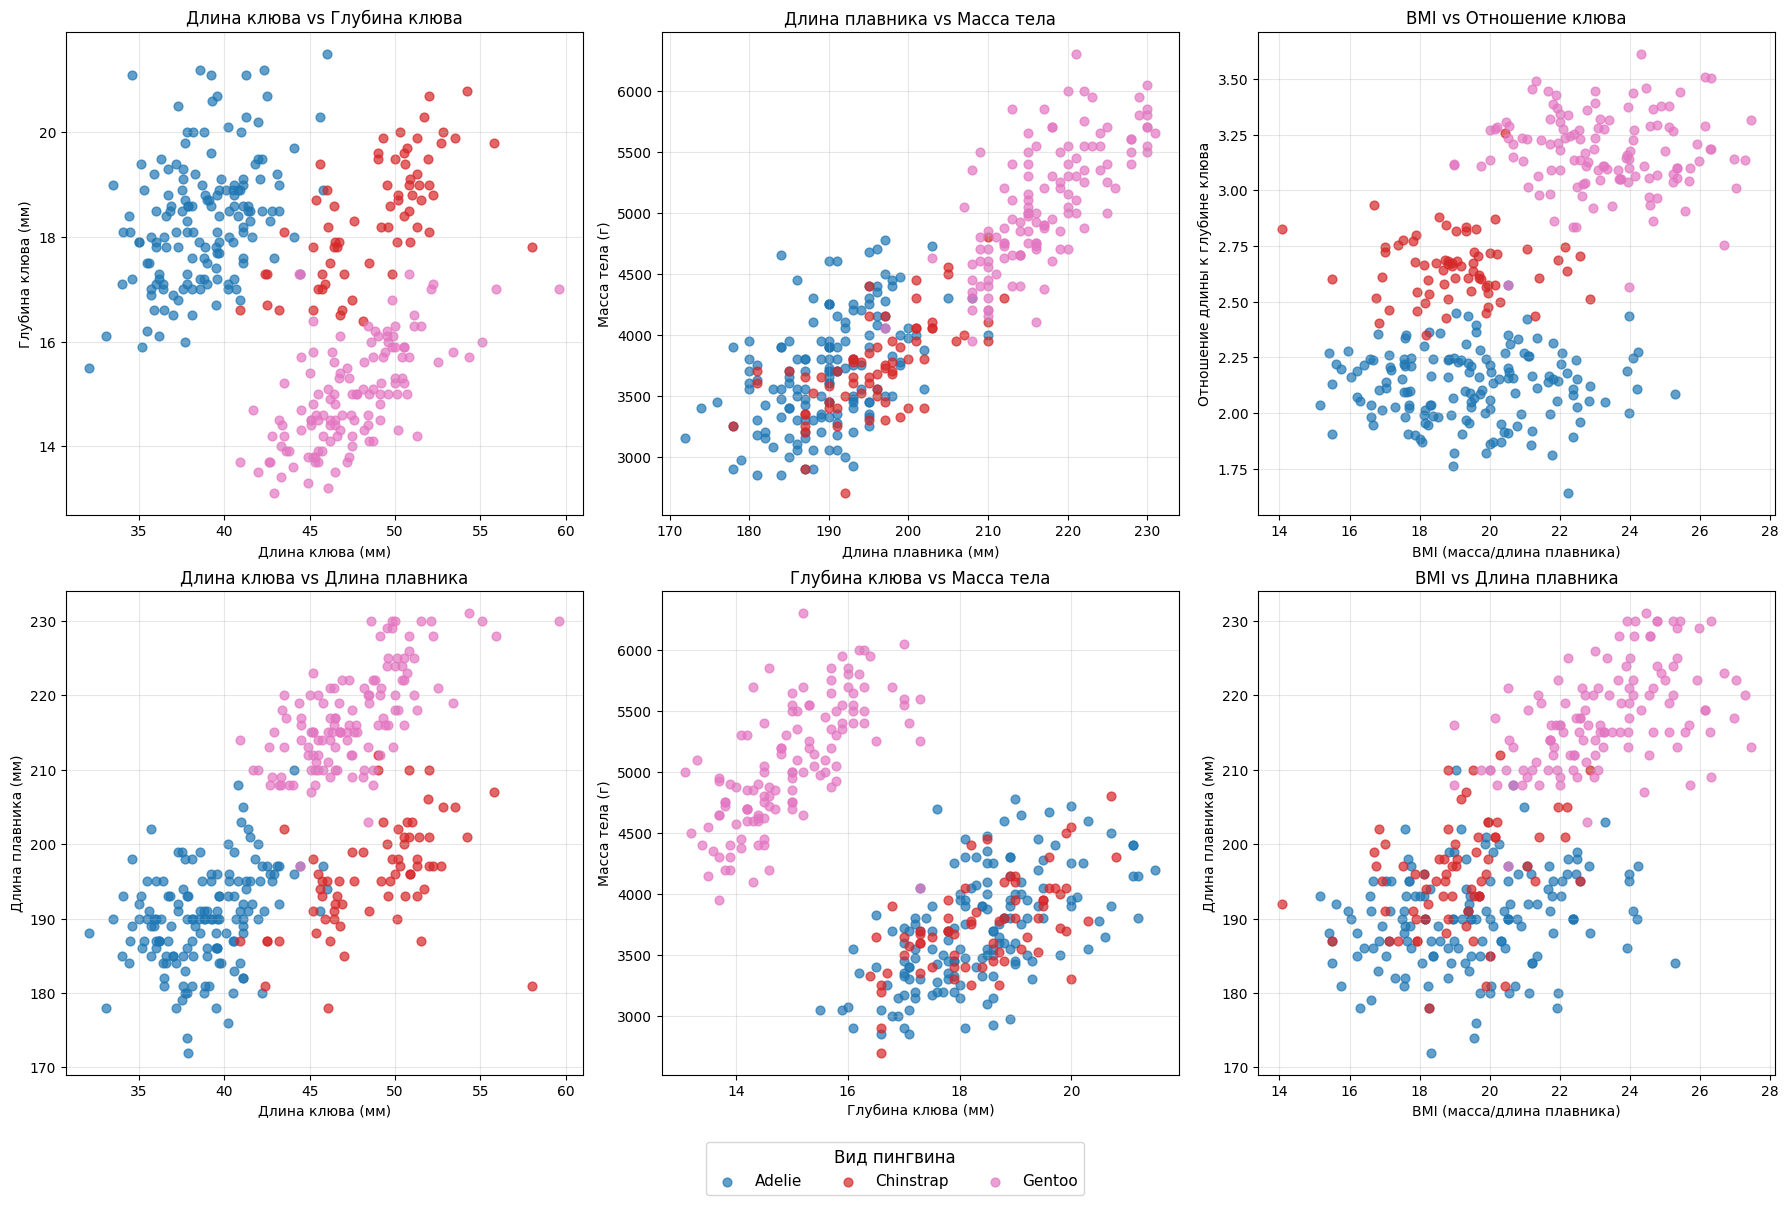


Наблюдаемые кластеры:

1. На графике 'Длина клюва vs Глубина клюва':
Четко видны 3 кластера, соответствующие разным видам пингвинов.

2. На графике 'Длина плавника vs Масса тела':
Отдельный кластер вида Gentoo, другие два вида похожи.

3. На графике 'BMI vs Отношение клюва':
Видно разделение на 3 кластера по видам, по отношению длины к глубине клюва, независимо от BMI

4 На графике 'Длина клюва vs Длина плавника':
Четко видны 3 кластера, соответствующие разным видам пингвинов.

5. На графике 'Глубина клюва vs Масса тела':
Отдельный кластер вида Gentoo, другие два вида похожи

6. На графике 'BMI vs Длина плавника':
Также отдельный кластер вида Gentoo, другие два вида похожи


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

#Цветовая карта для видов
species_list = df['species'].unique()
color_map = plt.get_cmap('tab10')
species_colors_cmap = {species: color_map(i/len(species_list))
                      for i, species in enumerate(species_list)}

#График 1: Длина клюва vs Глубина клюва
for species, color in species_colors_cmap.items():
    species_data = df[df['species'] == species]
    axes[0, 0].scatter(species_data['bill_length_mm'], species_data['bill_depth_mm'],
                      color=color, label=species, alpha=0.7, s=40)
axes[0, 0].set_xlabel('Длина клюва (мм)')
axes[0, 0].set_ylabel('Глубина клюва (мм)')
axes[0, 0].set_title('Длина клюва vs Глубина клюва')
axes[0, 0].grid(True, alpha=0.3)

#График 2: Длина плавника vs Масса тела
for species, color in species_colors_cmap.items():
    species_data = df[df['species'] == species]
    axes[0, 1].scatter(species_data['flipper_length_mm'], species_data['body_mass_g'],
                      color=color, label=species, alpha=0.7, s=40)
axes[0, 1].set_xlabel('Длина плавника (мм)')
axes[0, 1].set_ylabel('Масса тела (г)')
axes[0, 1].set_title('Длина плавника vs Масса тела')
axes[0, 1].grid(True, alpha=0.3)

#График 3: BMI vs bill_ratio
for species, color in species_colors_cmap.items():
    species_data = df[df['species'] == species]
    axes[0, 2].scatter(species_data['bmi'], species_data['bill_ratio'],
                      color=color, label=species, alpha=0.7, s=40)
axes[0, 2].set_xlabel('BMI (масса/длина плавника)')
axes[0, 2].set_ylabel('Отношение длины к глубине клюва')
axes[0, 2].set_title('BMI vs Отношение клюва')
axes[0, 2].grid(True, alpha=0.3)

#График 4: Длина клюва vs Длина плавника
for species, color in species_colors_cmap.items():
    species_data = df[df['species'] == species]
    axes[1, 0].scatter(species_data['bill_length_mm'], species_data['flipper_length_mm'],
                      color=color, label=species, alpha=0.7, s=40)
axes[1, 0].set_xlabel('Длина клюва (мм)')
axes[1, 0].set_ylabel('Длина плавника (мм)')
axes[1, 0].set_title('Длина клюва vs Длина плавника')
axes[1, 0].grid(True, alpha=0.3)

#График 5: Глубина клюва vs Масса тела
for species, color in species_colors_cmap.items():
    species_data = df[df['species'] == species]
    axes[1, 1].scatter(species_data['bill_depth_mm'], species_data['body_mass_g'],
                      color=color, label=species, alpha=0.7, s=40)
axes[1, 1].set_xlabel('Глубина клюва (мм)')
axes[1, 1].set_ylabel('Масса тела (г)')
axes[1, 1].set_title('Глубина клюва vs Масса тела')
axes[1, 1].grid(True, alpha=0.3)

#График 6: BMI vs Длина плавника
for species, color in species_colors_cmap.items():
    species_data = df[df['species'] == species]
    axes[1, 2].scatter(species_data['bmi'], species_data['flipper_length_mm'],
                      color=color, label=species, alpha=0.7, s=40)
axes[1, 2].set_xlabel('BMI (масса/длина плавника)')
axes[1, 2].set_ylabel('Длина плавника (мм)')
axes[1, 2].set_title('BMI vs Длина плавника')
axes[1, 2].grid(True, alpha=0.3)

#Легенда для всего графика
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Вид пингвина',
           loc='upper center', bbox_to_anchor=(0.5, 0.05),
           ncol=3, fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

print("\nНаблюдаемые кластеры:")

print("\n1. На графике 'Длина клюва vs Глубина клюва':")
print("Четко видны 3 кластера, соответствующие разным видам пингвинов.")

print("\n2. На графике 'Длина плавника vs Масса тела':")
print("Отдельный кластер вида Gentoo, другие два вида похожи.")

print("\n3. На графике 'BMI vs Отношение клюва':")
print("Видно разделение на 3 кластера по видам, по отношению длины к глубине клюва, независимо от BMI")

print("\n4 На графике 'Длина клюва vs Длина плавника':")
print("Четко видны 3 кластера, соответствующие разным видам пингвинов.")

print("\n5. На графике 'Глубина клюва vs Масса тела':")
print("Отдельный кластер вида Gentoo, другие два вида похожи")

print("\n6. На графике 'BMI vs Длина плавника':")
print("Также отдельный кластер вида Gentoo, другие два вида похожи")


4. ПРИМЕНЕНИЕ МЕТОДА KMEANS


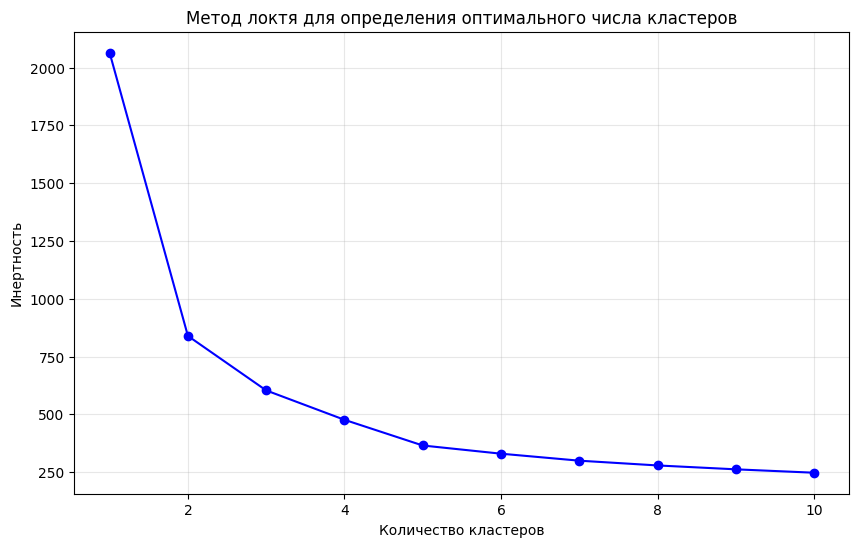

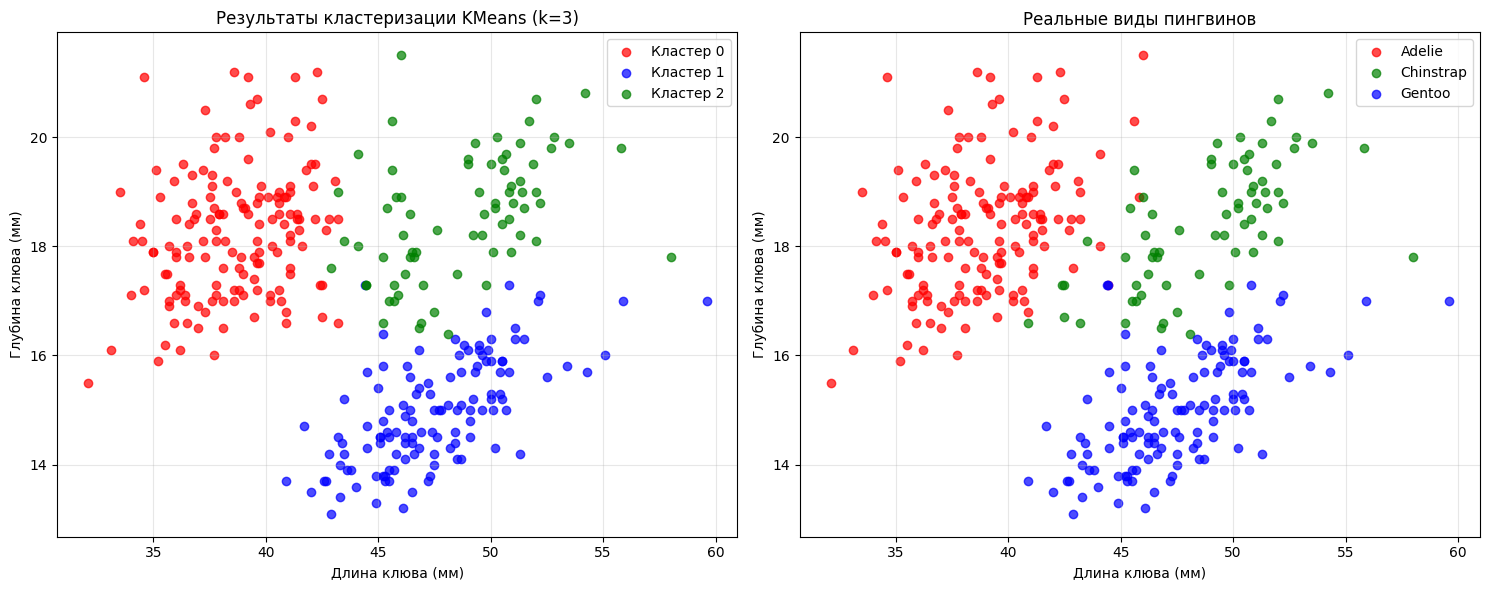


Распределение видов по кластерам KMeans:
species  Adelie  Chinstrap  Gentoo
cluster                           
0           144          5       0
1             0          0     123
2             8         63       1

Метрики качества кластеризации:
Adjusted Rand Index: 0.8939
Silhouette Score: 0.4264


In [ ]:
print("\n4. ПРИМЕНЕНИЕ МЕТОДА KMEANS")

#Выберем числовые признаки для кластеризации
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'bmi', 'bill_ratio']
X = df[features]

#Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Метод локтя для определения оптимального числа кластеров
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

#График метода локтя
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Инертность')
plt.title('Метод локтя для определения оптимального числа кластеров')
plt.grid(True, alpha=0.3)
plt.show()

#Применяем KMeans с оптимальным количеством кластеров
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

#Визуализация результатов кластеризации
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Цвета для кластеров
cluster_colors = ['red', 'blue', 'green']

#Визуализация в пространстве двух признаков
for cluster_num in range(3):
    cluster_data = df[df['cluster'] == cluster_num]
    axes[0].scatter(cluster_data['bill_length_mm'], cluster_data['bill_depth_mm'],
                   color=cluster_colors[cluster_num], alpha=0.7, label=f'Кластер {cluster_num}')

axes[0].set_xlabel('Длина клюва (мм)')
axes[0].set_ylabel('Глубина клюва (мм)')
axes[0].set_title('Результаты кластеризации KMeans (k=3)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

#Цвета для видов
species_colors = ['red', 'green', 'blue']

#Правильное отображение видов: 0:Adelie, 1:Chinstrap, 2:Gentoo
species_mapping = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
species_colors_map = {species: species_colors[species_mapping[species]] for species in df['species'].unique()}

#Сравнение с реальными видами
for species, color in species_colors_map.items():
    species_data = df[df['species'] == species]
    axes[1].scatter(species_data['bill_length_mm'], species_data['bill_depth_mm'],
                   color=color, alpha=0.7, label=species)

axes[1].set_xlabel('Длина клюва (мм)')
axes[1].set_ylabel('Глубина клюва (мм)')
axes[1].set_title('Реальные виды пингвинов')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

#Анализ распределения видов по кластерам
print("\nРаспределение видов по кластерам KMeans:")
cluster_species = pd.crosstab(df['cluster'], df['species'])
print(cluster_species)

#Оценка качества кластеризации (совпадение с реальными видами)
from sklearn.metrics import adjusted_rand_score, silhouette_score

#Преобразуем виды в числовые метки с правильным порядком
species_labels = df['species'].map(species_mapping)

#Вычисляем метрики
ari = adjusted_rand_score(species_labels, df['cluster'])
silhouette = silhouette_score(X_scaled, df['cluster'])

print(f"\nМетрики качества кластеризации:")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

In [ ]:
print("\n5. ВЫВОДЫ")

print("\nВизуализация выявила четкие кластеры:")
print("   - Три вида пингвинов образуют хорошо разделимые группы")
print("   - Наиболее различимы пингвины Gentoo (большая масса, длинные плавники)")
print("   - Adelie и Chinstrap ближе друг к другу, но различаются параметрами клюва")

print("\nКластеризация KMeans показала:")
print("   - Оптимальное количество кластеров: 3 (совпадает с числом видов)")
print("   - Кластеры KMeans хорошо соответствуют реальным видам")
print("   - Adjusted Rand Index: {:.4f} - хорошее совпадение".format(ari))
print("   - Silhouette Score: {:.4f} - кластеры хорошо разделены".format(silhouette))


5. ВЫВОДЫ

Визуализация выявила четкие кластеры:
   - Три вида пингвинов образуют хорошо разделимые группы
   - Наиболее различимы пингвины Gentoo (большая масса, длинные плавники)
   - Adelie и Chinstrap ближе друг к другу, но различаются параметрами клюва

Кластеризация KMeans показала:
   - Оптимальное количество кластеров: 3 (совпадает с числом видов)
   - Кластеры KMeans хорошо соответствуют реальным видам
   - Adjusted Rand Index: 0.8939 - хорошее совпадение
   - Silhouette Score: 0.4264 - кластеры хорошо разделены
